# mRESIST Analysis for Mouse Tumor Data
### Demonstrating the Gao et al. (2015) criteria on PDX/Xenograft data

## 1. Rationale
In human clinical trials, the **RECIST** (Response Evaluation Criteria in Solid Tumors) guidelines are the gold standard for measuring how a patient responds to treatment. However, translating RECIST directly to mouse models—specifically Patient-Derived Xenografts (PDX)—presents major challenges:
* Mice are typically monitored for much shorter periods.
* Tumor volume is often measured directly (calipers) rather than by cross-sectional imaging.
* Mouse tumor growth dynamics are highly aggressive compared to human timelines.

To address this, **Gao et al. (2015)** established **mRESIST** (mouse RECIST). Instead of relying on a single time-point scan, mRESIST leverages a **Best Average Response** metric. This looks at the rolling average of tumor volume changes to smooth out measurement noise and capture the true biological trajectory of the treatment response.

### Criteria Summary:
* **CR (Complete Response):** Best response $\le -95\%$ and Best Average Response $\le -40\%$
* **PR (Partial Response):** Best response $\le -50\%$ and Best Average Response $\le -20\%$
* **SD (Stable Disease):** Best response $\le 35\%$ and Best Average Response $\le 30\%$
* **PD (Progressive Disease):** Anything failing to meet the above.

## References
> Gao, H., Korn, J.M., Ferretti, S. et al. "High-throughput screening using patient-derived tumor xenografts to predict clinical trial drug response." *Nat Med* 21, 1318–1325 (2015). https://doi.org/10.1038/nm.3954

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Import the custom mresist module and the test data provided
# Ensure survivalvolume is in your python path, or run this notebook in the directory containing it!
from survivalvolume.mresist import (
    calculate_mresist_gao,
    mresist_fisher_stats,
    auto_run_mresist_stats,
    plot_mresist_waterfall
)
from survivalvolume.tests.test_data import test_data

# Enable inline plotting for the notebook
%matplotlib inline

## 2. Data Overview
Let's take a look at the shape of the test data. The data dictionary contains three distinct treatment groups (`vehicle`, `other_treatment`, and `good_treatment`), with mice mapped to their measured tumor volumes on given days.

In [2]:
print(f"Treatment Groups available: {list(test_data.keys())}\n")

# Peek at the 'vehicle' group data
print("Vehicle Group Sample Data:")
display(test_data['vehicle'].head())

Treatment Groups available: ['other_treatment', 'vehicle', 'good_treatment']

Vehicle Group Sample Data:


,6666,6661,6663,6665,6664,6669,6668,6667
1,189.20,181.22,261.01,219.89,204.29,207.047,209.51,211.23
4,278.13,277.63,552.57,243.41,344.84,270.520,317.32,199.20
8,274.69,300.63,414.30,592.57,346.97,265.350,276.04,154.58
11,347.82,570.15,557.21,416.23,351.16,276.190,244.11,317.42
15,507.35,584.07,725.49,725.89,575.32,300.780,225.95,326.65


## 3. Running the mRESIST Categorization
Now we apply the `calculate_mresist_gao` function. We pass a `cutoff_day=21` limit to mirror typical trial windows. Mice that drop off or stop recording before this window without hitting standard endpoints are flagged as `Censored`.

In [3]:
details_df, summary_df = calculate_mresist_gao(test_data, cutoff_day=10)

print("mRESIST Summary Table per Treatment Group:")
display(summary_df)

print("\nDetailed Per-Mouse Metrics (First 5 Rows):")
display(details_df.head())

mRESIST Summary Table per Treatment Group:


mRESIST,CR,PR,SD,PD,Censored
Group,,,,,
good_treatment,0,0,3,0,2
other_treatment,0,0,8,0,1
vehicle,0,0,8,0,0



Detailed Per-Mouse Metrics (First 5 Rows):


,Group,MouseID,Best_Response (%),Day_of_Best,Best_Avg_Response (%),mRESIST
0,other_treatment,7777,0.00,1,0.00,SD
1,other_treatment,7778,0.00,1,0.00,SD
2,other_treatment,7787,0.00,1,0.00,SD
3,other_treatment,7770,-34.66,8,-15.77,Censored
4,other_treatment,7774,0.00,1,0.00,SD


## 4. Statistical Evaluations
We've categorized the mice, but are the treatment outcomes actually statistically significant?

The pipeline evaluates this in two ways:
1. **Categorical (Fisher's Exact Test):** Evaluates if the responder rate (CR + PR + SD) vs. non-responders (PD) is statistically different between the pairwise groups, applying a Benjamini-Hochberg (FDR) correction.
2. **Continuous (ANOVA or Kruskal-Wallis):** Evaluates the raw `Best Average Response (%)` metrics directly, dynamically selecting the appropriate test based on a Shapiro-Wilk normality check.

In [4]:
print("--- Categorical Analysis (Fisher's Exact) ---")
fisher_results = mresist_fisher_stats(summary_df)
display(fisher_results)

print("\n--- Continuous Analysis Pipeline ---")
continuous_results = auto_run_mresist_stats(details_df)
display(continuous_results)

--- Categorical Analysis (Fisher's Exact) ---


,Comparison,G1_Rate,G2_Rate,P_Raw,P_Adj_FDR,Significant
0,good_treatment vs other_treatment,3/3,8/8,1.0,1.0,False
1,good_treatment vs vehicle,3/3,8/8,1.0,1.0,False
2,other_treatment vs vehicle,8/8,8/8,1.0,1.0,False



--- Continuous Analysis Pipeline ---
Normality Check Summary:
             Group  N  P_Shapiro      Status
0   good_treatment  3     0.9434      Normal
1  other_treatment  8     0.0000  Non-Normal
2          vehicle  8     0.0000  Non-Normal

Recommended Test: Kruskal-Wallis



,Test,H_Stat,P_Value
0,Kruskal-Wallis,3.890693,0.142938


## 5. Visualizing Response with a Waterfall Plot
To pull it all together, we can visualize the specific treatment response of each individual mouse on a waterfall plot. This provides a visual representation of how the 'Good Treatment' outshines the 'Vehicle' or 'Other Treatment'.

<module 'matplotlib.pyplot' from '/Users/wakefield/PycharmProjects/survivalvolume/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

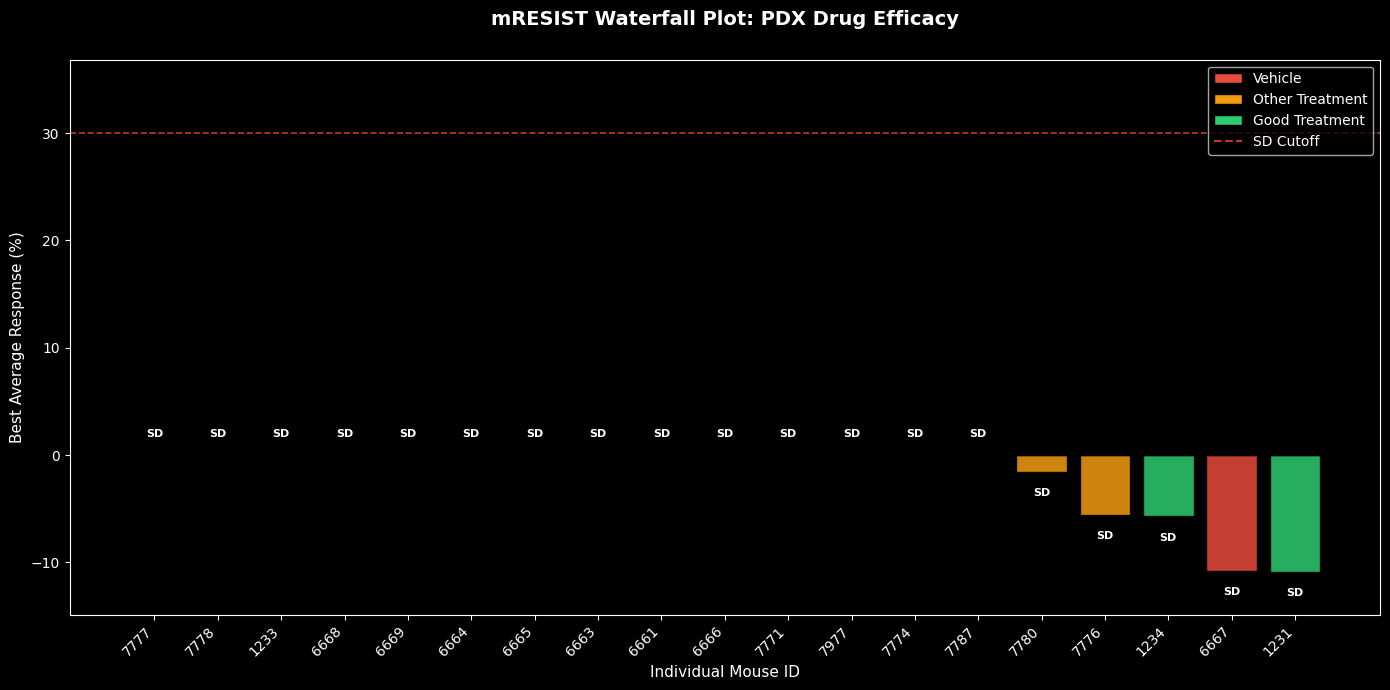

In [5]:
# Create custom colors for the plot
custom_colors = {
    'vehicle': '#e74c3c',          # Red
    'other_treatment': '#f39c12',  # Orange
    'good_treatment': '#2ecc71'    # Green
}

plot_mresist_waterfall(
    details_df,
    colors=custom_colors,
    show_labels=True,
    title="mRESIST Waterfall Plot: PDX Drug Efficacy"
)